In [46]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [47]:
df_statistics = pd.read_csv("../../data/processed_data/dataset_information/genomes_info_with_partitions.csv")
df_statistics = df_statistics.rename(columns={"Unnamed: 0":"accession"})

accessions = df_statistics["accession"]

In [70]:
cds_lengths = []
cds_lengths_family = dict()
cds_lengths_domain = dict()

for accession in accessions:

    df_accession = df_statistics[df_statistics["accession"] == accession]
    family = df_accession["family"].values[0]
    domain = df_accession["domain"].values[0]

    if family not in cds_lengths_family.keys():
        cds_lengths_family[family] = []

    if domain not in cds_lengths_domain.keys():
        cds_lengths_domain[domain] = []

    with open(f"../../data/raw_data/genome_data/{accession}/genomic.gff", "r") as infile_genomic_gff:
        for line in infile_genomic_gff:
            if len(line.split("\t")) < 7:
                continue
            else:
                info_attributes = line.split("\t")
                attr = info_attributes[2]
                landmark = info_attributes[0]
                
                if attr == "CDS":
                    #Get CDS start and end coordinates
                    cds_start = int(info_attributes[3])
                    cds_end = int(info_attributes[4])

                    cds_length = cds_end - cds_start + 1

                    if cds_length % 3 == 0:
                        cds_lengths.append(cds_length)

                        cds_lengths_family[family].append(cds_length)
                        cds_lengths_domain[domain].append(cds_length)

# Plot overall histogram

In [71]:
median_cds_length = np.median(cds_lengths)

In [73]:
np.mean(cds_lengths)

np.float64(961.9163976841587)

In [75]:
cds_lengths_array = np.array(cds_lengths)
percentage = (sum(cds_lengths_array > 300) / len(cds_lengths_array)) * 100
print(f"Percentage of CDS longer than 300: {percentage:.2f}%")

Percentage of CDS longer than 300: 90.08%


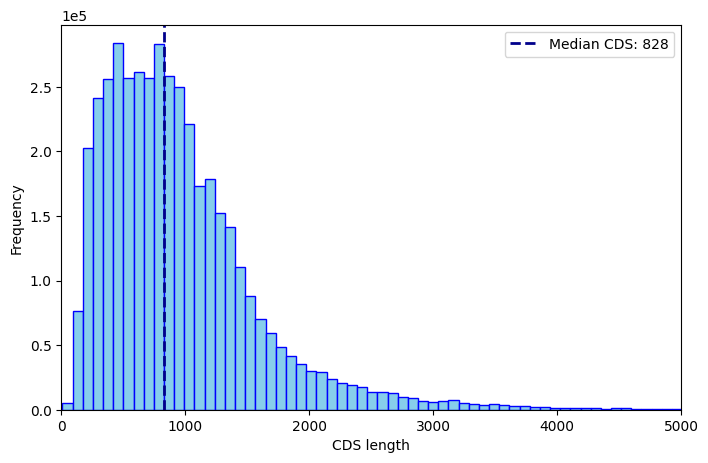

In [72]:
plt.figure(figsize=(8,5))
plt.hist(cds_lengths, bins = 1000, color = 'skyblue', edgecolor = 'blue')
plt.axvline(median_cds_length, color='darkblue', linestyle='--', linewidth=2, label=f'Median CDS: {median_cds_length:.0f}')
plt.xlabel("CDS length")
plt.ylabel("Frequency")
plt.xlim(0, 5000)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
plt.show()

# Plot length distribution for longest and shortest CDS families

In [52]:
#Still not sure if it makes sense to plot something on family-level
cds_lengths_median_family = dict()

for family in cds_lengths_family.keys():
    cds_lengths_median_family[family] = int(np.median(cds_lengths_family[family]))